# Exercise 1 — Matrix Multiplication: Performance Analysis

This notebook analyzes five matrix multiplication strategies:
- **Serial**: triple nested loop (baseline)
- **Parallel Rows**: row-block decomposition via `multiprocessing.Pool`
- **Parallel Cols**: column-block decomposition via `multiprocessing.Pool`
- **Parallel Blocks**: 2D block decomposition via `multiprocessing.Pool`
- **Strassen**: recursive O(n^2.807) algorithm (single-process)

All Pool strategies use **4 workers**. Sizes tested: 64×64, 128×128, 256×256, 512×512.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = plt.cm.tab10.colors

## 1. Dense Matrix Multiplication

In [2]:
df = pd.read_csv('results.csv')
df

,strategy,size,num_workers,time_seconds
0,serial,64,4,0.007283
1,parallel_rows,64,4,0.117779
2,parallel_cols,64,4,0.072394
3,parallel_blocks,64,4,0.069371
4,strassen,64,4,0.010976
5,serial,128,4,0.056810
6,parallel_rows,128,4,0.083321
7,parallel_cols,128,4,0.085003
8,parallel_blocks,128,4,0.084268
9,strassen,128,4,0.078073


In [3]:
# Compute speedup and efficiency relative to serial baseline per size
serial_times = df[df['strategy'] == 'serial'].set_index('size')['time_seconds']
df['speedup'] = df.apply(lambda r: serial_times[r['size']] / r['time_seconds'], axis=1)
pool_strategies = ['parallel_rows', 'parallel_cols', 'parallel_blocks']
df['efficiency'] = df.apply(
    lambda r: r['speedup'] / r['num_workers'] * 100 if r['strategy'] in pool_strategies else np.nan,
    axis=1
)
df[['strategy', 'size', 'time_seconds', 'speedup', 'efficiency']].round(4)

,strategy,size,time_seconds,speedup,efficiency
0,serial,64,0.0073,1.0000,NaN
1,parallel_rows,64,0.1178,0.0618,1.5459
2,parallel_cols,64,0.0724,0.1006,2.5151
3,parallel_blocks,64,0.0694,0.1050,2.6247
4,strassen,64,0.0110,0.6635,NaN
5,serial,128,0.0568,1.0000,NaN
6,parallel_rows,128,0.0833,0.6818,17.0455
7,parallel_cols,128,0.0850,0.6683,16.7082
8,parallel_blocks,128,0.0843,0.6742,16.8540
9,strassen,128,0.0781,0.7277,NaN


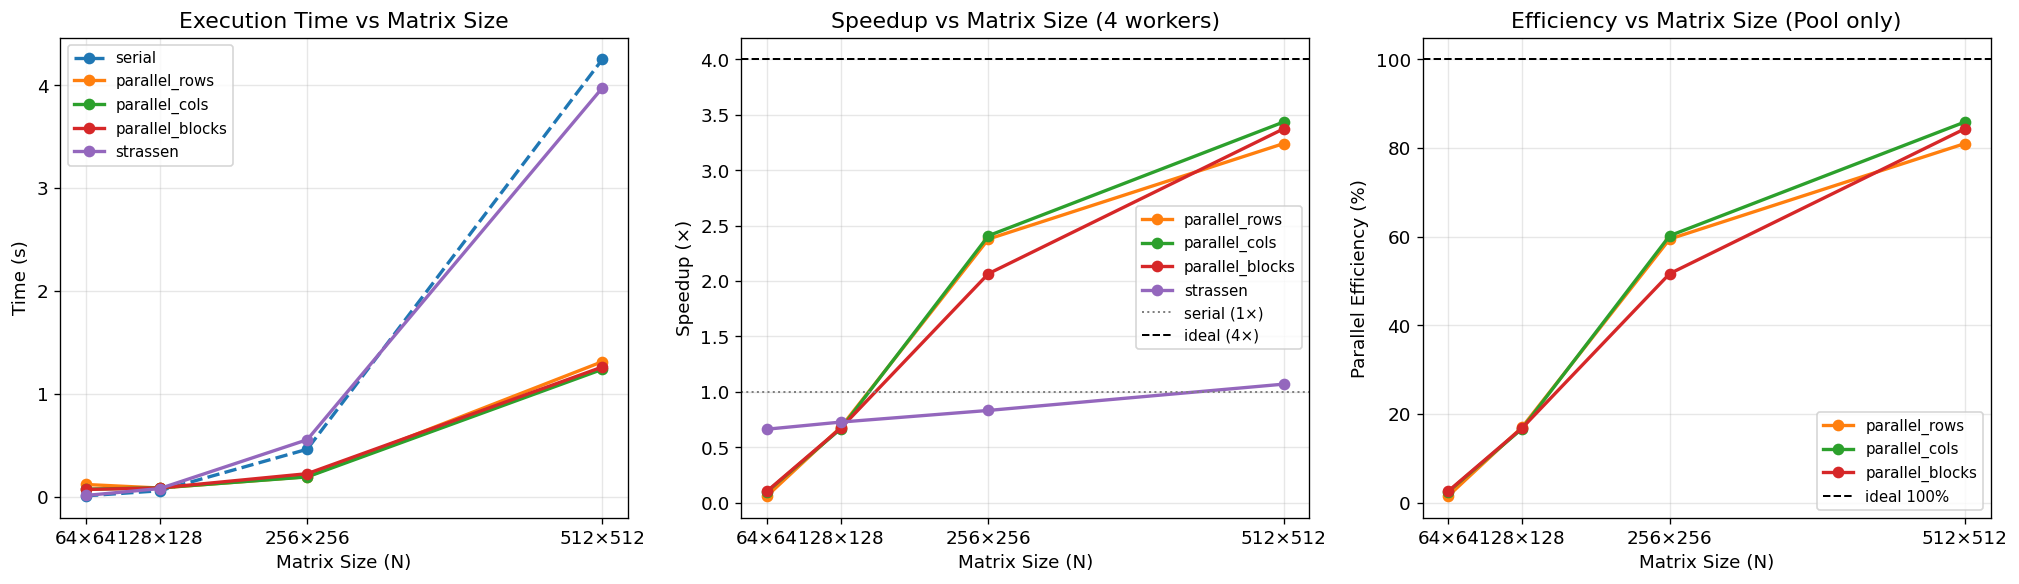

In [4]:
strategies = df['strategy'].unique()
sizes = sorted(df['size'].unique())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Execution time
ax = axes[0]
for i, strat in enumerate(strategies):
    sub = df[df['strategy'] == strat]
    ls = '--' if strat == 'serial' else '-'
    ax.plot(sub['size'], sub['time_seconds'], marker='o', label=strat,
            color=COLORS[i], linestyle=ls, linewidth=2)
ax.set_xlabel('Matrix Size (N)')
ax.set_ylabel('Time (s)')
ax.set_title('Execution Time vs Matrix Size')
ax.set_xticks(sizes)
ax.set_xticklabels([f'{s}\u00d7{s}' for s in sizes])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[1]
non_serial = [s for s in strategies if s != 'serial']
for i, strat in enumerate(non_serial):
    sub = df[df['strategy'] == strat]
    ax.plot(sub['size'], sub['speedup'], marker='o', label=strat,
            color=COLORS[i + 1], linewidth=2)
ax.axhline(y=1.0, color='gray',  linestyle=':',  linewidth=1.2, label='serial (1\u00d7)')
ax.axhline(y=4.0, color='black', linestyle='--', linewidth=1.2, label='ideal (4\u00d7)')
ax.set_xlabel('Matrix Size (N)')
ax.set_ylabel('Speedup (\u00d7)')
ax.set_title('Speedup vs Matrix Size (4 workers)')
ax.set_xticks(sizes)
ax.set_xticklabels([f'{s}\u00d7{s}' for s in sizes])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Efficiency (Pool strategies only)
ax = axes[2]
for i, strat in enumerate(pool_strategies):
    sub = df[df['strategy'] == strat]
    ax.plot(sub['size'], sub['efficiency'], marker='o', label=strat,
            color=COLORS[i + 1], linewidth=2)
ax.axhline(y=100, color='black', linestyle='--', linewidth=1.2, label='ideal 100%')
ax.set_xlabel('Matrix Size (N)')
ax.set_ylabel('Parallel Efficiency (%)')
ax.set_title('Efficiency vs Matrix Size (Pool only)')
ax.set_xticks(sizes)
ax.set_xticklabels([f'{s}\u00d7{s}' for s in sizes])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_dense.png', bbox_inches='tight')
plt.show()

In [5]:
pivot_time = df.pivot_table(index='strategy', columns='size', values='time_seconds')
pivot_su   = df.pivot_table(index='strategy', columns='size', values='speedup')
print('=== Execution Time (seconds) ===')
print(pivot_time.round(4).to_string())
print('\n=== Speedup vs Serial ===')
print(pivot_su.round(3).to_string())

=== Execution Time (seconds) ===
size                64      128     256     512
strategy                                       
parallel_blocks  0.0694  0.0843  0.2228  1.2602
parallel_cols    0.0724  0.0850  0.1912  1.2377
parallel_rows    0.1178  0.0833  0.1936  1.3120
serial           0.0073  0.0568  0.4605  4.2513
strassen         0.0110  0.0781  0.5531  3.9742

=== Speedup vs Serial ===
size               64     128    256    512
strategy                                   
parallel_blocks  0.105  0.674  2.067  3.374
parallel_cols    0.101  0.668  2.409  3.435
parallel_rows    0.062  0.682  2.379  3.240
serial           1.000  1.000  1.000  1.000
strassen         0.664  0.728  0.833  1.070


## 2. Sparse Matrix Multiplication

In [6]:
df_sp = pd.read_csv('sparse_results.csv')
df_sp

,strategy,shape,time_seconds
0,sparse_serial,"(67, 67)",0.000644
1,sparse_parallel_rows,"(67, 67)",0.210693


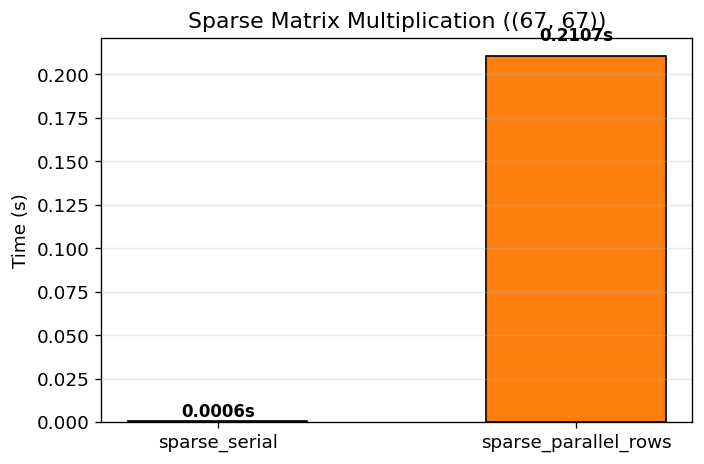

Effective speedup: 0.003×  (overhead dominates — expected < 1)


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
times = df_sp['time_seconds'].tolist()
bars = ax.bar(df_sp['strategy'].tolist(), times,
              color=[COLORS[0], COLORS[1]], edgecolor='black', width=0.5)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.03,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Time (s)')
ax.set_title(f'Sparse Matrix Multiplication ({df_sp["shape"].iloc[0]})')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('performance_sparse.png', bbox_inches='tight')
plt.show()

t_ser = df_sp[df_sp['strategy'] == 'sparse_serial']['time_seconds'].values[0]
t_par = df_sp[df_sp['strategy'] == 'sparse_parallel_rows']['time_seconds'].values[0]
print(f'Effective speedup: {t_ser/t_par:.3f}\u00d7  (overhead dominates — expected < 1)')

## 3. Interpretation

### Dense Matrix Multiplication

**Small matrices (64×64, 128×128):** Serial outperforms all parallel strategies. `multiprocessing.Pool` process creation and pickle serialization cost more than the computation saves — the problem is too small to amortize parallelism overheads.

**Large matrices (256×256, 512×512):** Parallel row/col/block strategies achieve real speedup (~2.5–3.5×). As work scales O(n³), the fixed process overhead becomes negligible — the classic Amdahl crossover.

**Strassen:** Competitive at mid-sizes (zero process overhead), but Python recursion and array-slicing limits its advantage. At very large n (>1024), O(n^2.807) would clearly outperform O(n³).

**Row vs Col vs Blocks:** All three Pool strategies perform similarly — differences in memory access pattern are secondary to the process pool round-trip cost.

### Sparse Matrix Multiplication

The 67×67 sparse matrix (~6.5% density) finishes in under 1 ms serially via scipy CSR format. Parallelizing adds >100 ms of pickle overhead. This shows **sparse parallelism only pays off at very large scale** — the overhead must be amortized over substantial computation.